In [25]:
import sys
sys.path.append("../src")

import GOenrichment as ge
import importlib

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/diff/proneural_rna_diff.csv",
    "Classical": "../data/interim/diff/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/diff/mesenchymal_rna_diff.csv"
}




Proneural
Significant genes after filtering: 3417
Proneural: BP UP
Proneural: BP DOWN
Proneural: CC UP
Proneural: CC DOWN
Proneural: MF UP
Proneural: MF DOWN


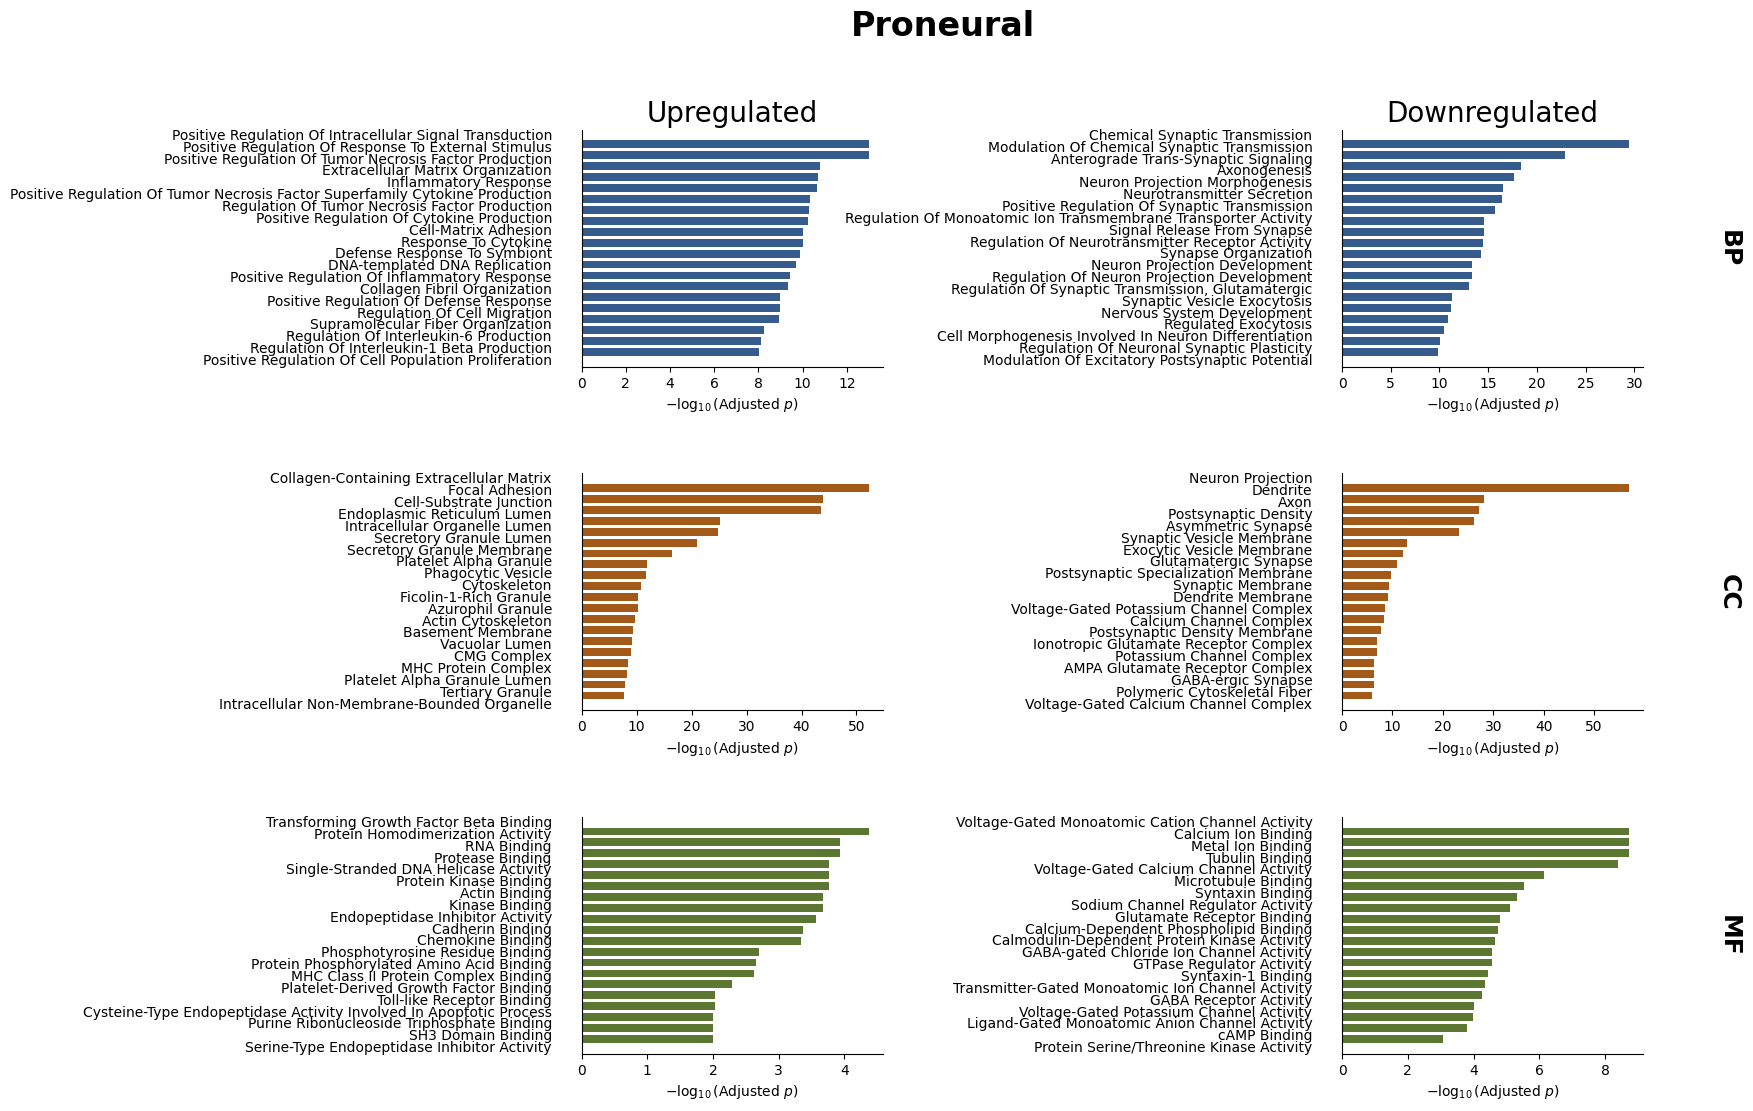


Classical
Significant genes after filtering: 3767
Classical: BP UP
Classical: BP DOWN
Classical: CC UP
Classical: CC DOWN
Classical: MF UP
Classical: MF DOWN


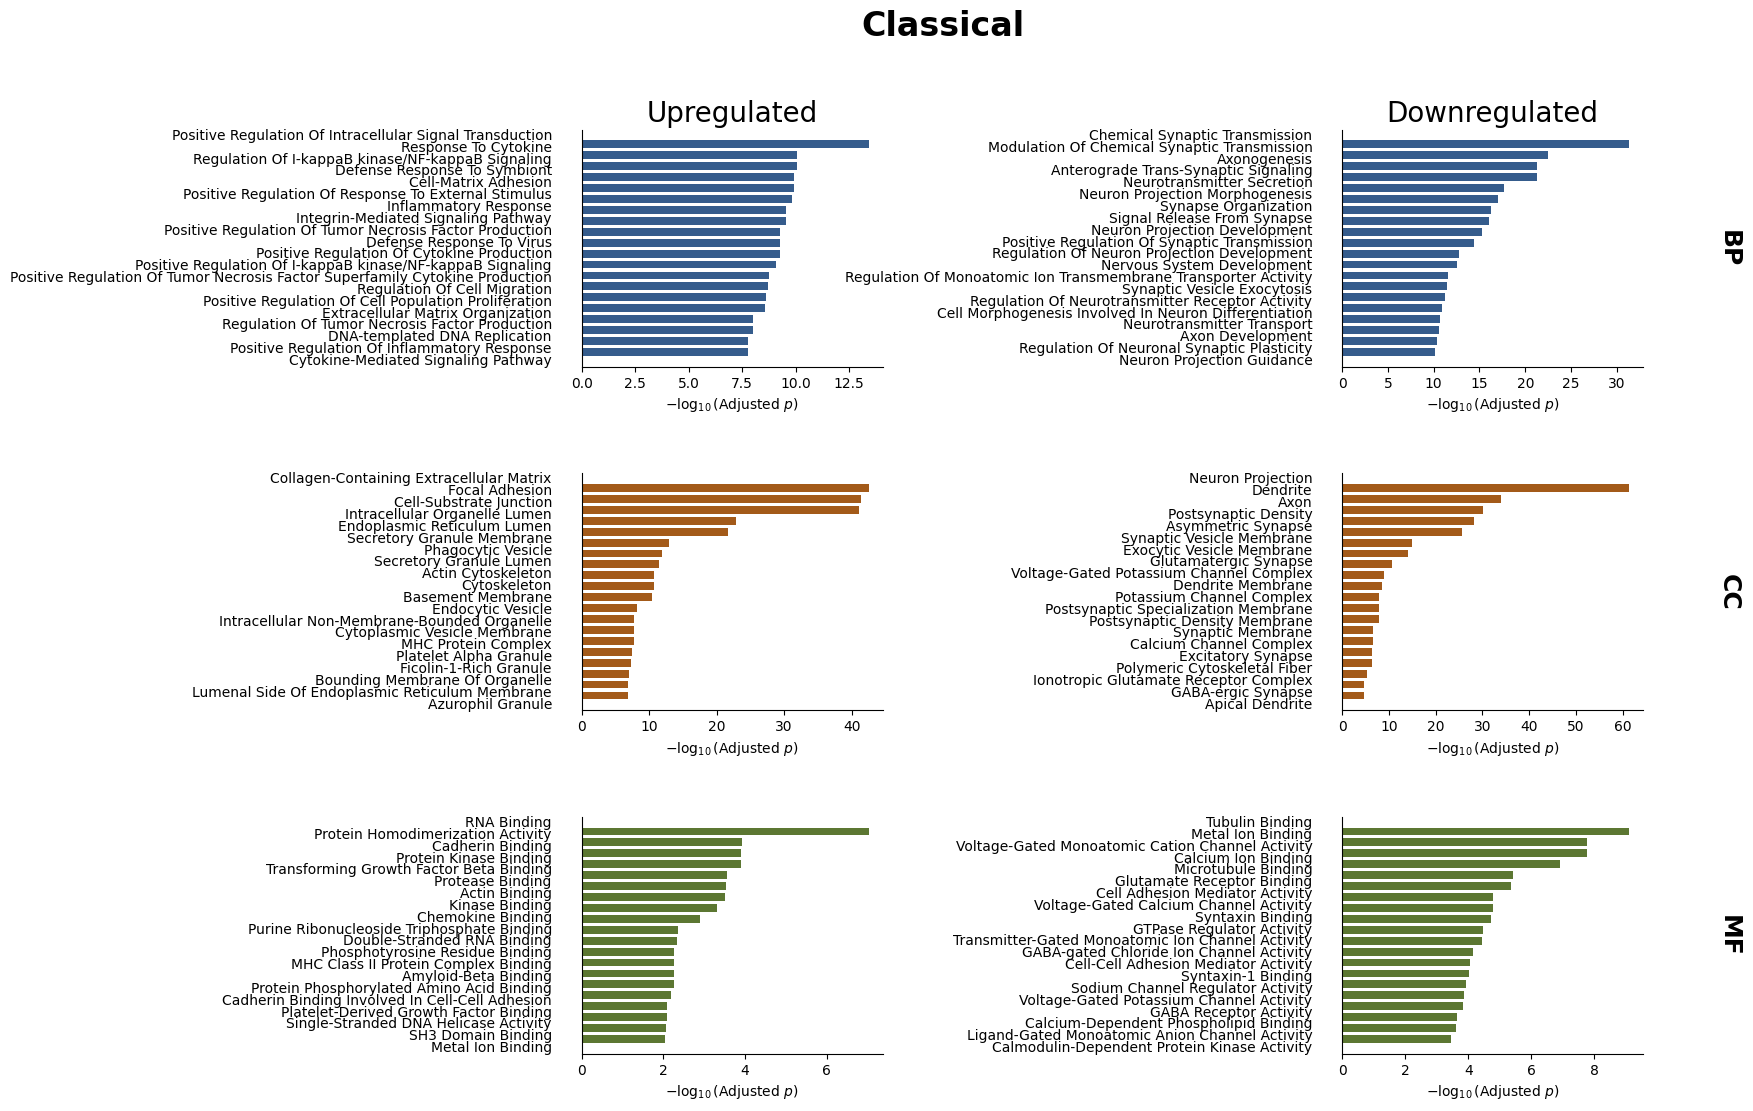


Mesenchymal
Significant genes after filtering: 4071
Mesenchymal: BP UP
Mesenchymal: BP DOWN
Mesenchymal: CC UP
Mesenchymal: CC DOWN
Mesenchymal: MF UP
Mesenchymal: MF DOWN


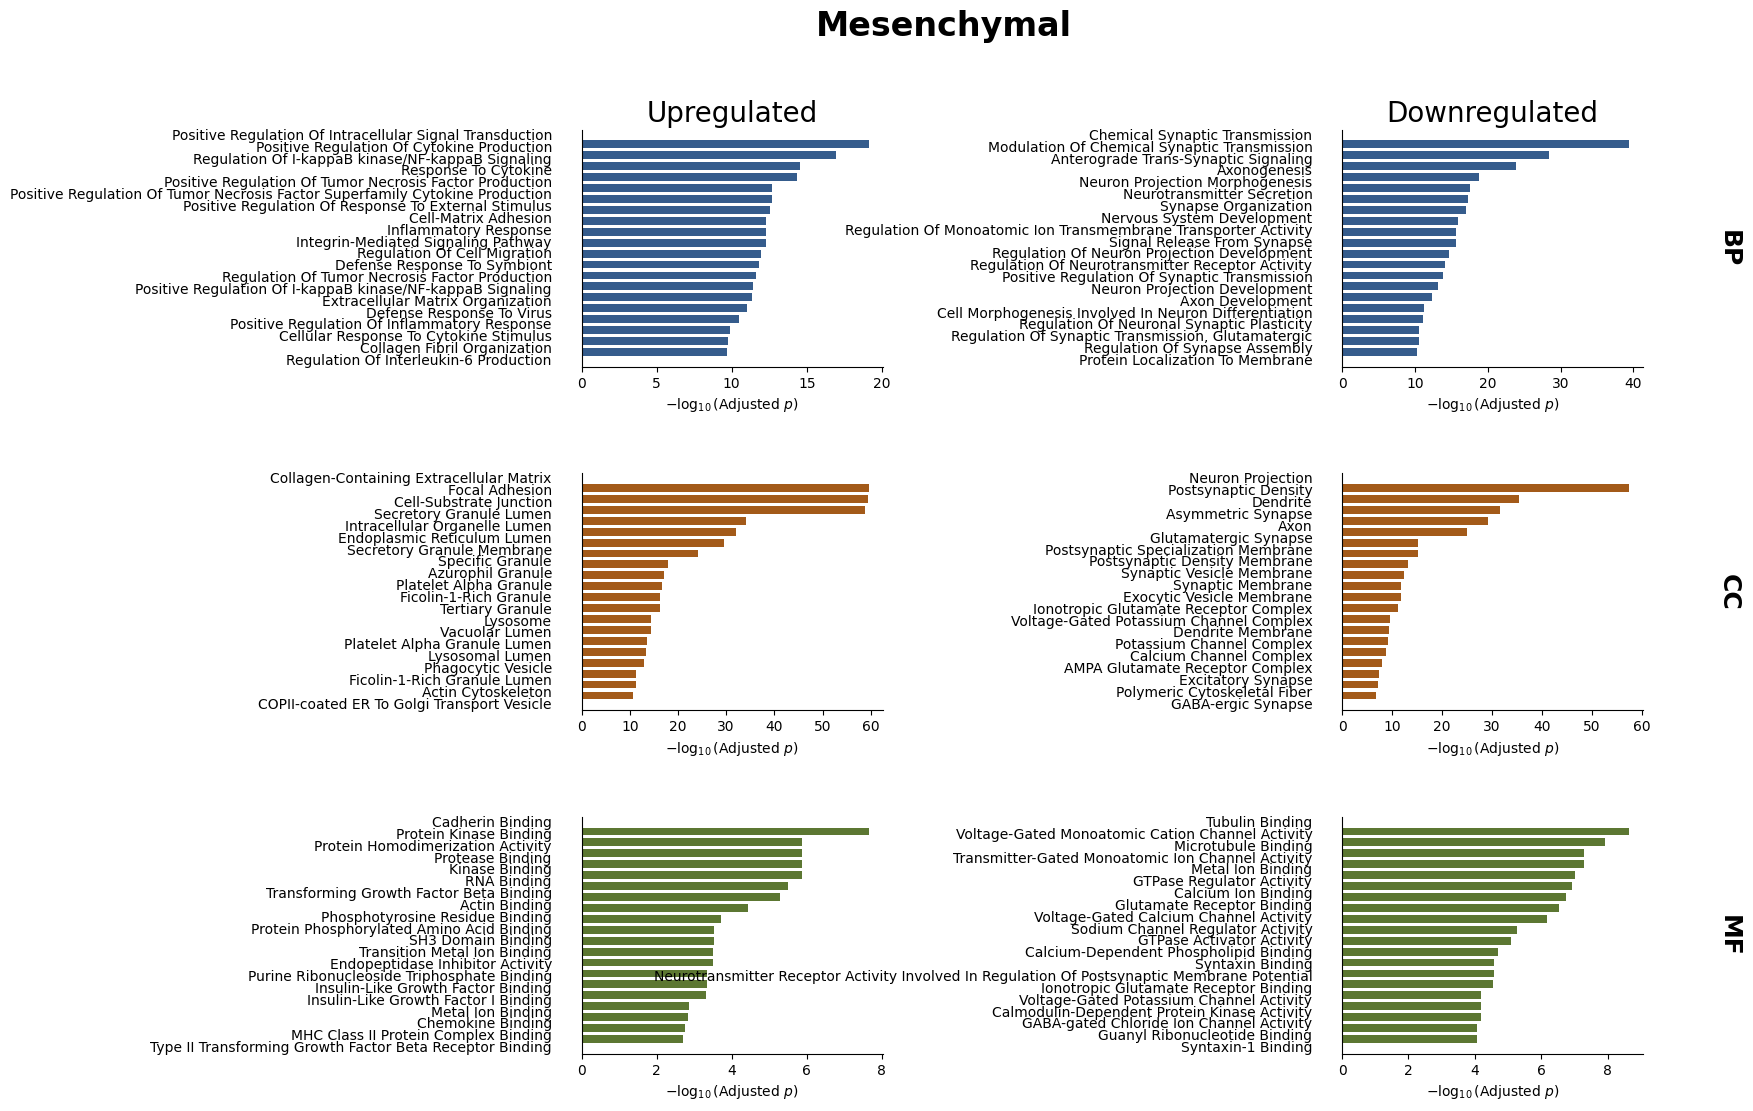

In [26]:
for subtype, file in files.items():
    ge.analyze_subtype(
        file,
        subtype,
        direction="split"
    )


Proneural
Significant genes after filtering: 3417
Proneural: BP
Proneural: CC
Proneural: MF


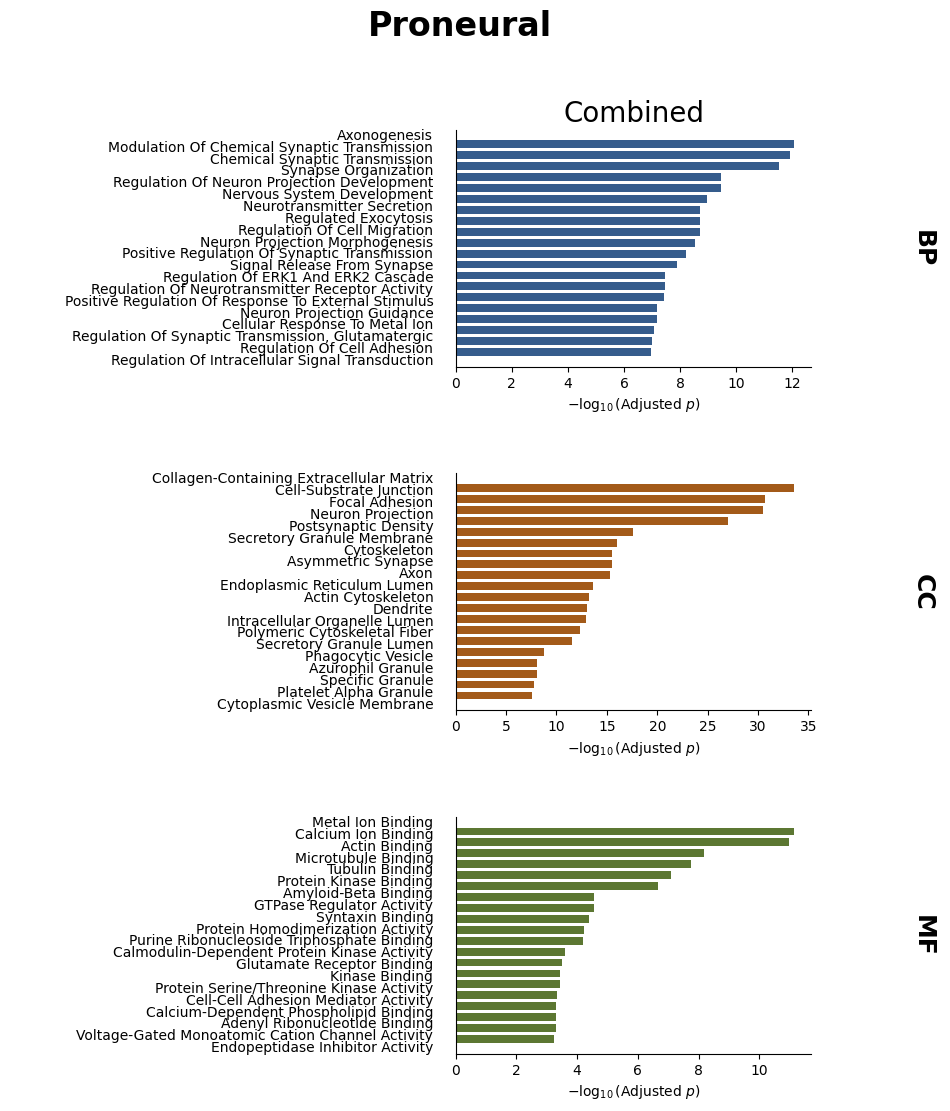


Classical
Significant genes after filtering: 3767
Classical: BP
Classical: CC
Classical: MF


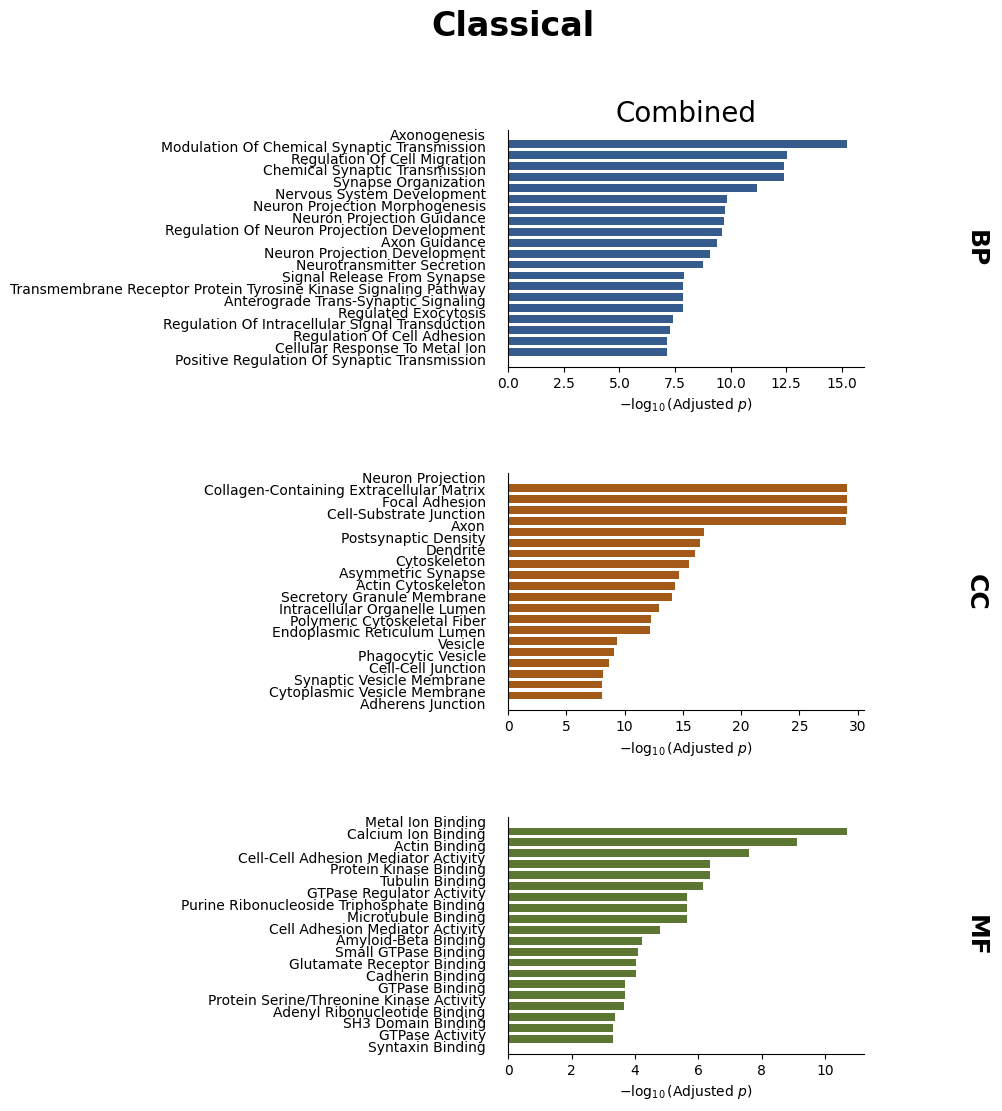


Mesenchymal
Significant genes after filtering: 4071
Mesenchymal: BP
Mesenchymal: CC
Mesenchymal: MF


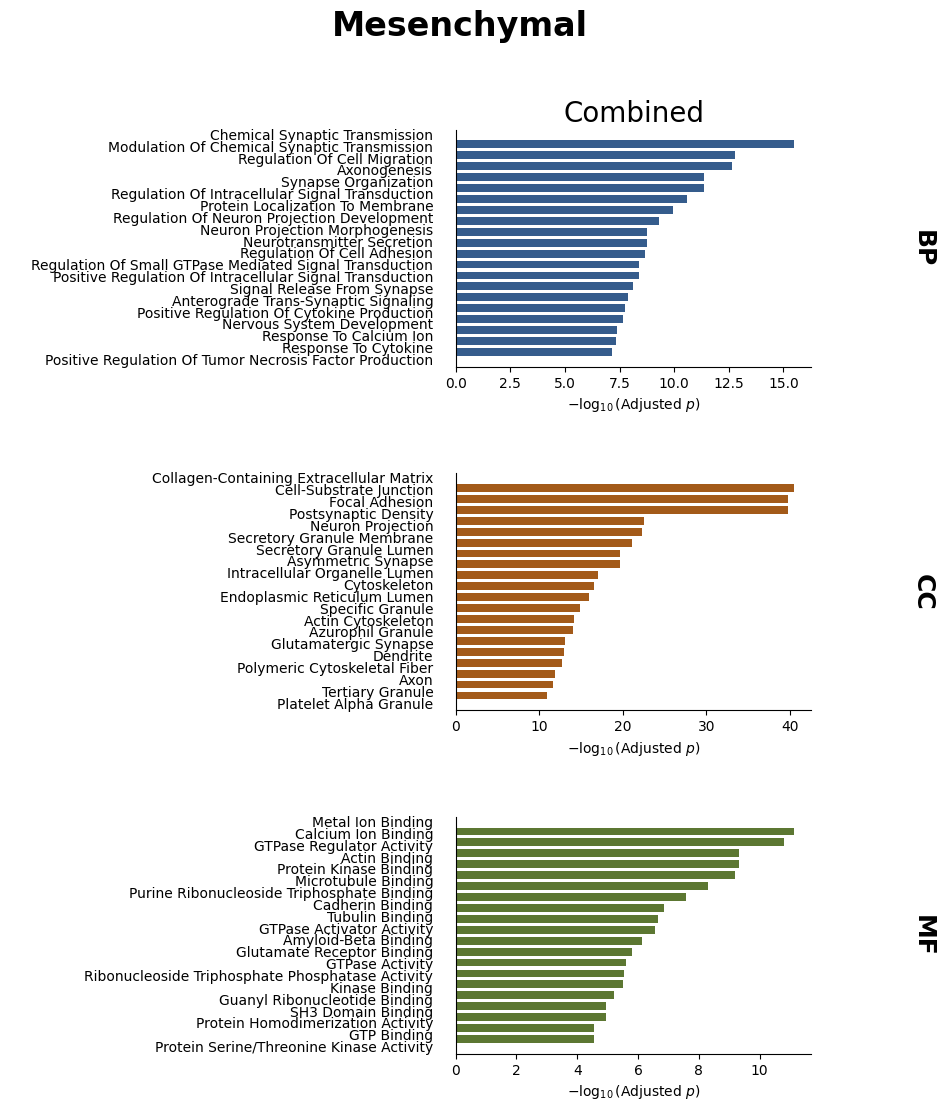

In [28]:
go_combined = {}

for subtype, file in files.items():
    go_combined[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined"
    )


In [35]:
mesenchymal_keywords = [
    "apop",
    "programmed cell death",
    "pyrop",
    "necrop",
    "ferrop",
    "autophag",
    "cell death",
    "casp",
    "BCL2",
    "BAX",
    "intrinsic apoptotic"
]

mesen_pattern = "|".join(mesenchymal_keywords)

mes = go_combined["Mesenchymal"]["BP"].copy()

mes["Rank"] = range(1, len(mes) + 1)

hits_mes = mes[
        mes["Term"].str.contains(mesen_pattern, case=False, na=False)
    ]

print(f"\n===== Mesenchymal =====")

if hits_mes.empty:
    print("No matching GO terms found.")
else:
    print(
        hits_mes[["Rank", "Term", "Adjusted P-value"]]
            .to_string(index=False)
    )



===== Mesenchymal =====
 Rank                                                                                                   Term  Adjusted P-value
   89                                                  Positive Regulation Of Apoptotic Process (GO:0043065)          0.000041
   94                                              Positive Regulation Of Programmed Cell Death (GO:0043068)          0.000052
  126                                                           Regulation Of Apoptotic Process (GO:0042981)          0.000130
  157                                                  Negative Regulation Of Apoptotic Process (GO:0043066)          0.000233
  184                                           Positive Regulation Of Apoptotic Cell Clearance (GO:2000427)          0.000394
  203                                                    Regulation Of Neuron Apoptotic Process (GO:0043523)          0.000525
  361                                              Negative Regulation Of Programmed C

In [36]:
classical_keywords = [
    "apop",
    "programmed cell death",
    "pyrop",
    "necrop",
    "ferrop",
    "autophag",
    "cell death",
    "casp",
    "BCL2",
    "BAX",
    "intrinsic apoptotic"
]

clas_pattern = "|".join(classical_keywords)

clas = go_combined["Classical"]["BP"].copy()

clas["Rank"] = range(1, len(clas) + 1)

hits_clas = clas[
        clas["Term"].str.contains(clas_pattern, case=False, na=False)
    ]

print(f"\n===== Classical =====")

if hits_clas.empty:
    print("No matching GO terms found.")
else:
    print(
        hits_clas[["Rank", "Term", "Adjusted P-value"]]
            .to_string(index=False)
    )



===== Classical =====
 Rank                                                                                                 Term  Adjusted P-value
  138                                         Positive Regulation Of Apoptotic Cell Clearance (GO:2000427)          0.000305
  179                                                         Regulation Of Apoptotic Process (GO:0042981)          0.000709
  229                                            Positive Regulation Of Programmed Cell Death (GO:0043068)          0.001563
  247                                                Negative Regulation Of Apoptotic Process (GO:0043066)          0.002027
  266                                                  Regulation Of Neuron Apoptotic Process (GO:0043523)          0.002345
  374                                                Positive Regulation Of Apoptotic Process (GO:0043065)          0.007641
  383                                         Negative Regulation Of Neuron Apoptotic Process (GO:0043

In [37]:
proneural_keywords = [
    "apop",
    "programmed cell death",
    "pyrop",
    "necrop",
    "ferrop",
    "autophag",
    "cell death",
    "casp",
    "BCL2",
    "BAX",
    "intrinsic apoptotic"
]

bp = go_combined["Proneural"]["BP"].copy()
bp["Rank"] = range(1, len(bp) + 1)

proneural_hits = bp[
    bp["Term"].str.contains(
        "|".join(proneural_keywords),
        case=False,
        na=False
    )
]

print(proneural_hits[["Rank", "Term", "Adjusted P-value"]].to_string(index=False))

 Rank                                                                                                   Term  Adjusted P-value
  117                                           Positive Regulation Of Apoptotic Cell Clearance (GO:2000427)          0.000177
  326                                              Positive Regulation Of Programmed Cell Death (GO:0043068)          0.005955
  393                                                           Regulation Of Apoptotic Process (GO:0042981)          0.009207
  444                                                  Positive Regulation Of Apoptotic Process (GO:0043065)          0.013784
  448                                        Positive Regulation Of Leukocyte Apoptotic Process (GO:2000108)          0.014046
  519                                                    Regulation Of Apoptotic Cell Clearance (GO:2000425)          0.021130
  562          Regulation Of Cysteine-Type Endopeptidase Activity Involved In Apoptotic Process (GO:0043281)   